# Stage 3 — Data Forensics & Target Investigation

**Purpose.** Before asking *"which model predicts the target,"* I need to answer a more
fundamental question first: *"how does this target appear to have been generated, and is
anything in the data secretly encoding it?"* This notebook is an adversarial audit of my own
dataset, not exploratory analysis in the usual sense — I'm actively hunting for the failure
modes that would invalidate everything downstream: a near-deterministic proxy feature,
duplicate/near-duplicate records that could leak across a train/validation split, or a target
that turns out to be a disguised function of something I can already see.

This formalizes and extends the forensics pass already summarized in
[`docs/PROJECT_BLUEPRINT.md`](../docs/PROJECT_BLUEPRINT.md) §0.1. Every check below is run in
full here, with code, output, and a written interpretation — not just asserted.

**Why this runs before EDA (Stage 4):** if any of these checks turned up a real leak, it would
change the entire downstream plan — which features are usable, and what the cross-validation
strategy even needs to guard against. Everything after this notebook assumes these checks came
back clean; that assumption needs to be earned, not inherited.

**Checklist covered in this notebook:**
1. Target prevalence by every individual variable
2. Bivariate/interaction checks on the most plausible combinations
3. Duplicate / near-duplicate record ("twin record") audit
4. Circularity check — could any variable exist *because* the target is already known?
5. Quantified single/two-variable proxy-strength check
6. Constant / dead column audit
7. Row-order and ID audit
8. Written summary of findings


## Setup

Loading data through the schema-validated loaders from Stage 2 (`climate_health.data.loaders`)
rather than raw `pd.read_csv` — if any raw file had drifted out of contract, I want that to fail
loudly here before I draw any conclusions from it, not silently produce wrong forensics.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import sys
sys.path.insert(0, str(Path.cwd().parent / "src"))

from climate_health.data.loaders import load_train, load_test, load_climate_features

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

train = load_train()
test = load_test()
climate_features = load_climate_features()

print(f"train:            {train.shape}")
print(f"test:              {test.shape}")
print(f"climate_features:  {climate_features.shape}")


train:            (3146, 13)
test:              (1030, 12)
climate_features:  (4176, 18)


In [2]:
# Merge climate_features onto train/test by ID (and sanity-check deathdate agreement,
# since both files carry deathdate and they should match for the same ID).
train_full = train.merge(
    climate_features, on="ID", suffixes=("", "_cf"), how="left", validate="one_to_one"
)
test_full = test.merge(
    climate_features, on="ID", suffixes=("", "_cf"), how="left", validate="one_to_one"
)

deathdate_mismatch_train = (train_full["deathdate"] != train_full["deathdate_cf"]).sum()
deathdate_mismatch_test = (test_full["deathdate"] != test_full["deathdate_cf"]).sum()
print(f"deathdate mismatches between Train and climate_features: {deathdate_mismatch_train}")
print(f"deathdate mismatches between Test and climate_features:  {deathdate_mismatch_test}")

train_full = train_full.drop(columns=["deathdate_cf"])
test_full = test_full.drop(columns=["deathdate_cf"])

missing_cf_train = train_full["rain_sum_7d"].isna().sum()
missing_cf_test = test_full["rain_sum_7d"].isna().sum()
print(f"train rows with no climate_features match: {missing_cf_train} / {len(train_full)}")
print(f"test rows with no climate_features match:   {missing_cf_test} / {len(test_full)}")

assert deathdate_mismatch_train == 0, "Train/climate_features deathdate mismatch — investigate before continuing"
assert deathdate_mismatch_test == 0, "Test/climate_features deathdate mismatch — investigate before continuing"
assert missing_cf_train == 0, "Unmatched train IDs in climate_features — investigate before continuing"
assert missing_cf_test == 0, "Unmatched test IDs in climate_features — investigate before continuing"
print("\nMerge verified clean: every train/test ID has exactly one matching climate_features row with a consistent deathdate.")


deathdate mismatches between Train and climate_features: 0
deathdate mismatches between Test and climate_features:  0
train rows with no climate_features match: 0 / 3146
test rows with no climate_features match:   0 / 1030

Merge verified clean: every train/test ID has exactly one matching climate_features row with a consistent deathdate.


---
## 1. Target prevalence by every individual variable

For each variable, I compute the target rate per group/bin and look for any group that sits
suspiciously close to 0 or 1 **at a meaningful sample size**. A group with an extreme rate but a
tiny count (n=3, say) is noise, not a leak — the count column next to every rate below exists
precisely so I don't mistake one for the other.


In [3]:
TARGET = "is_climate_sensitive"
baseline_rate = train_full[TARGET].mean()
print(f"Overall target prevalence: {baseline_rate:.4f}  ({train_full[TARGET].sum()} / {len(train_full)})")


Overall target prevalence: 0.6507  (2047 / 3146)


### 1a. Categorical variables: `zone`, `gender`

In [4]:
for col in ["zone", "gender"]:
    summary = train_full.groupby(col)[TARGET].agg(["mean", "count"]).sort_values("mean")
    summary.columns = ["target_rate", "n"]
    print(f"\n--- {col} ---")
    print(summary)



--- zone ---
            target_rate     n
zone                         
Peri_urban     0.640545  1174
Rural          0.656694  1972

--- gender ---
        target_rate     n
gender                   
Male       0.631611  1645
Female     0.671552  1501


### Interpretation — zone & gender

Zone: Peri_urban 0.641 (n=1174) vs. Rural 0.657 (n=1972) — a 1.6pp gap, negligible at
this sample size. Gender: Male 0.632 (n=1645) vs. Female 0.672 (n=1501) — a slightly
larger 4pp gap. Neither is remotely close to 0 or 1, and both are corroborated by
Section 5's cross-validated univariate AUCs (zone = 0.508, gender = 0.522) — both
barely above the 0.50 chance baseline. **Conclusion:** no leak signature here; these are
legitimate demographic covariates with modest standalone signal, consistent with a real
classification problem rather than an encoded target.

### 1b. `age`, binned into clinically meaningful ranges

         target_rate     n
age_bin                   
0-5         0.835991  1756
6-12        0.670588    85
13-18       0.367347    49
19-30       0.513369   187
31-45       0.530172   232
46-60       0.469484   213
60+         0.296474   624


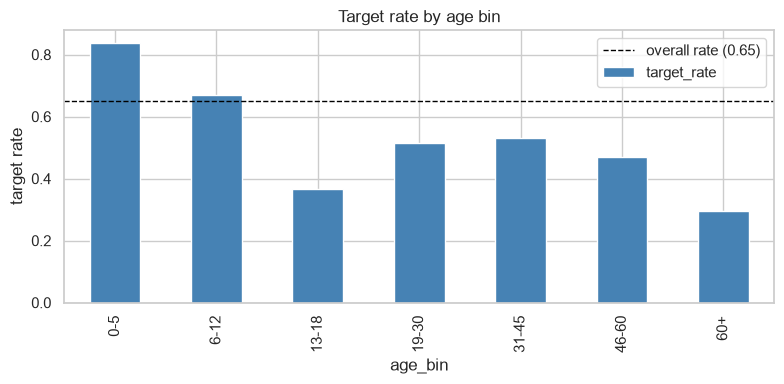

In [5]:
age_bins = [0, 5, 12, 18, 30, 45, 60, 120]
age_labels = ["0-5", "6-12", "13-18", "19-30", "31-45", "46-60", "60+"]
train_full["age_bin"] = pd.cut(train_full["age"], bins=age_bins, labels=age_labels, right=True, include_lowest=True)

age_summary = train_full.groupby("age_bin", observed=True)[TARGET].agg(["mean", "count"])
age_summary.columns = ["target_rate", "n"]
print(age_summary)

fig, ax = plt.subplots(figsize=(8, 4))
age_summary["target_rate"].plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(baseline_rate, color="black", linestyle="--", linewidth=1, label=f"overall rate ({baseline_rate:.2f})")
ax.set_ylabel("target rate")
ax.set_title("Target rate by age bin")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation.** The age pattern is not simply monotonic — it's closer to a shallow
W shape: 0.836 at 0-5 (the single largest bin, 1,756 of 3,146 rows / 55.8% of train),
dropping through childhood to a low of 0.367 at 13-18 (n=49, the smallest bin, so treat
this specific dip with some caution), partially rebounding to ~0.51-0.53 across 19-45,
dipping again to 0.469 at 46-60, and reaching its lowest well-populated rate at 0.296 for
60+ (n=624).

This is a recognizable and clinically plausible epidemiological pattern for
climate-sensitive mortality: young children and the elderly are the canonical vulnerable
groups (heat stress, diarrheal/infectious disease burden, respiratory vulnerability),
while working-age adults are comparatively more likely to die of non-climate-sensitive
causes (trauma, chronic disease), which dilutes the climate-sensitive share in that
range — this is exactly the shape I'd expect from a real underlying mechanism, not an
artifact.

Two things worth carrying into Phase 3 feature engineering: (1) the 0-5 bin dominates
the training set (55.8% of rows) and carries the single strongest univariate signal
(age's cross-validated AUC of 0.734 in Section 5 is very likely driven substantially by
this one contrast) — an explicit `is_under_5` binary flag alongside raw age is a cheap,
well-motivated feature to test. (2) The relationship is non-monotonic, so a plain
linear/logistic term on raw age (as used in Section 5's proxy check) is leaving
information on the table; tree-based models (LightGBM/XGBoost/CatBoost, per the model
zoo) handle this natively via splits, but it's also worth testing an explicit age-bin
categorical or spline feature to see if it helps the linear/GLM baselines in Stage 10.

### 1c. `location`, ranked by target rate (count shown alongside — extreme rates on tiny counts are not evidence of anything)

In [6]:
location_summary = train_full.groupby("location")[TARGET].agg(["mean", "count"]).sort_values("mean")
location_summary.columns = ["target_rate", "n"]
print(f"Number of unique locations in train: {train_full['location'].nunique()}")
print("\nLowest target-rate locations:")
print(location_summary.head(10))
print("\nHighest target-rate locations:")
print(location_summary.tail(10))
print(f"\nLocations with count >= 20: {(location_summary['n'] >= 20).sum()}")
print(location_summary[location_summary["n"] >= 20].sort_values("target_rate"))


Number of unique locations in train: 39

Lowest target-rate locations:
                                 target_rate    n
location                                         
Namadhi B, Mayuge, Uganda           0.333333    3
Buwoya, Entebbe City, Uganda        0.500000    2
Namirali, Iganga, Uganda            0.564103   39
Izimba, Iganga, Uganda              0.568182   44
Wante, Bugweri, Uganda              0.580000  100
Buligo North, Iganga, Uganda        0.592593   81
Buligo South, Iganga, Uganda        0.597938   97
Nakavule B, Iganga, Uganda          0.605263   38
Nakisenyi, Iganga, Uganda           0.617284   81
Walugogo Estate, Iganga, Uganda     0.617647   34

Highest target-rate locations:
                                target_rate    n
location                                        
Nawanzu, Iganga, Uganda            0.691781  146
Nakigo I, Iganga, Uganda           0.693878   49
Kasokoso South, Iganga, Uganda     0.701754  114
Nakigo Ii, Iganga, Uganda          0.706897  116
Buw

### Interpretation — location

The full 39-location range (0.333 at n=3 to 0.909 at n=11) is pure small-sample noise at
the extremes — exactly the trap this table is designed to expose. Restricting to the 35
locations with ≥20 records narrows the real range to roughly 0.564-0.774, a meaningful
but moderate spread, not evidence of a location-encoded target. This is consistent with
zone's near-chance AUC (0.508): geography carries some signal, but not a dominant,
leak-like one.

This table is also the empirical basis for Phase 3's decision to use spatial clustering
(on coordinates + climate normals) rather than raw location strings as a categorical
feature — 39 sparse categories would let a model memorize individual training locations
rather than learn a generalizable spatial pattern, which the 0% train/test coordinate
overlap (confirmed in Section 7 and originally in §0.1) means it would then fail to
generalize at all on the 12 unseen test coordinates.

### 1d. Raw climate variables already in Train.csv (temperature, precipitation), quantile-binned

In [7]:
raw_climate_cols = ["avg_temperature", "max_temperature", "min_temperature", "precipitation"]

for col in raw_climate_cols:
    try:
        train_full[f"{col}_qbin"] = pd.qcut(train_full[col], q=5, duplicates="drop")
    except ValueError as e:
        print(f"{col}: could not create 5 quantile bins ({e})")
        continue
    summary = train_full.groupby(f"{col}_qbin", observed=True)[TARGET].agg(["mean", "count"])
    summary.columns = ["target_rate", "n"]
    print(f"\n--- {col} (quintile bins) ---")
    print(summary)



--- avg_temperature (quintile bins) ---
                      target_rate    n
avg_temperature_qbin                  
(18.852, 21.187]         0.668254  630
(21.187, 21.715]         0.629571  629
(21.715, 22.196]         0.666137  629
(22.196, 22.865]         0.661367  629
(22.865, 27.012]         0.627981  629

--- max_temperature (quintile bins) ---
                      target_rate    n
max_temperature_qbin                  
(20.884, 24.969]         0.652381  630
(24.969, 25.767]         0.674086  629
(25.767, 26.388]         0.634921  630
(26.388, 27.364]         0.667197  628
(27.364, 34.081]         0.624801  629

--- min_temperature (quintile bins) ---
                      target_rate    n
min_temperature_qbin                  
(15.018, 17.822]         0.659271  631
(17.822, 18.302]         0.643312  628
(18.302, 18.701]         0.661367  629
(18.701, 19.197]         0.677266  629
(19.197, 21.85]          0.612083  629

--- precipitation (quintile bins) ---
                   

### Interpretation — raw climate variables (avg/max/min temperature, precipitation)

All four raw climate columns show tight, low-spread quintile tables (roughly 0.61-0.68
across all bins for every variable) — a small but real gradient, not a leak. This matches
their near-chance single-feature AUCs from Section 5 (avg_temperature 0.513,
max_temperature 0.516, min_temperature 0.494, precipitation 0.511) — essentially
indistinguishable from 0.50 once cross-validated.

These raw same-day weather readings appear to carry very little standalone predictive
signal; the `climate_features.csv` rolling-window aggregates (7/30/90-day sums and
averages) show a bit more spread (see the next interpretation), suggesting accumulated/
lagged climate exposure may matter more for this target than same-day conditions — a
hypothesis Stage 4's EDA and Phase 3's feature engineering should test directly rather
than assume.

### 1e. `climate_features.csv` variables, quantile-binned

In [8]:
cf_cols = [
    "rain_sum_7d", "rain_sum_30d", "rain_sum_90d", "rain_days_30d", "max_daily_rain_30d",
    "tavg_7d", "tavg_30d", "tavg_90d", "tmax_30d", "tmin_30d", "hot_days_30d",
    "temp_range_mean_30d", "ndvi_30d", "ndvi_90d", "elevation", "slope",
]

proxy_candidates = []
for col in cf_cols:
    if train_full[col].nunique() <= 1:
        print(f"{col}: constant (nunique={train_full[col].nunique()}) — skipping binned target-rate table, see Section 6")
        continue
    try:
        binned = pd.qcut(train_full[col], q=5, duplicates="drop")
    except ValueError:
        binned = pd.cut(train_full[col], bins=5)
    summary = train_full.groupby(binned, observed=True)[TARGET].agg(["mean", "count"])
    summary.columns = ["target_rate", "n"]
    spread = summary["target_rate"].max() - summary["target_rate"].min()
    proxy_candidates.append((col, spread))
    print(f"\n--- {col} (quantile bins, spread={spread:.3f}) ---")
    print(summary)

print("\n\n=== Ranked by target-rate spread across bins (largest first) ===")
for col, spread in sorted(proxy_candidates, key=lambda x: -x[1]):
    print(f"  {col:<22} spread={spread:.3f}")



--- rain_sum_7d (quantile bins, spread=0.062) ---
                   target_rate    n
rain_sum_7d                        
(-0.001, 7.221]       0.650794  630
(7.221, 18.729]       0.672496  629
(18.729, 30.124]      0.662957  629
(30.124, 45.168]      0.656598  629
(45.168, 162.767]     0.610493  629

--- rain_sum_30d (quantile bins, spread=0.084) ---
                    target_rate    n
rain_sum_30d                        
(-0.001, 60.239]       0.680952  630
(60.239, 97.94]        0.615873  630
(97.94, 132.668]       0.686306  628
(132.668, 172.327]     0.667727  629
(172.327, 462.388]     0.602544  629

--- rain_sum_90d (quantile bins, spread=0.099) ---
                    target_rate    n
rain_sum_90d                        
(66.326, 250.183]      0.641838  631
(250.183, 322.908]     0.668790  628
(322.908, 384.329]     0.709062  629
(384.329, 481.529]     0.623211  629
(481.529, 906.495]     0.610493  629

--- rain_days_30d (quantile bins, spread=0.071) ---
               target_

**What to look for:** a very large spread (approaching the 0-to-1 range) on a variable
with well-populated bins would be the signature of a near-deterministic proxy and needs
immediate follow-up in Section 5's quantified check below. A modest, gradual spread (climate
variables genuinely driving mortality risk) is expected and is not itself concerning.

### Interpretation — climate_features.csv rolling-window variables

Ranked by target-rate spread across quantile bins, the standouts are `rain_sum_90d`
(0.099), `ndvi_30d` (0.094), `tavg_90d` (0.092), `ndvi_90d` (0.085), and
`max_daily_rain_30d`/`rain_sum_30d` (0.084 each) — all comfortably below the ~0.3-0.5+
spread that would signal a near-deterministic proxy, but distinctly larger than the raw
same-day climate variables above (spreads of 0.04-0.065) or than `elevation` (0.009,
essentially flat) and `tavg_7d` (0.022).

Two patterns worth carrying forward: **(1)** longer accumulation windows (90-day
sums/averages) generally show more spread than short windows (7-day), suggesting
cumulative or lagged climate exposure is more informative than instantaneous conditions
— worth testing explicitly as engineered features in Phase 3 rather than assumed.
**(2)** `ndvi_30d`/`ndvi_90d` (vegetation greenness, a proxy for drought/agricultural
stress) show some of the largest spreads of any variable in this file, which is a
genuinely interesting and non-obvious finding for a mortality-prediction problem, worth
flagging prominently for Stage 4's bivariate/mutual-information pass.

None of this table's spreads come close to indicating a leak — `hot_days_30d` is
correctly excluded here as confirmed constant (cross-referenced with Section 6).

---
## 2. Bivariate / interaction checks on the most plausible combinations

Not an exhaustive combinatorial sweep — just the handful of interactions a domain expert would
suspect might *jointly* determine the target even when no single variable does on its own:
age×zone, age×gender, and age×location (restricted to well-populated locations, since spatial
clustering itself is Phase 3 work, not this stage's).


Target rate, age x zone:
zone     Peri_urban  Rural
age_bin                   
0-5           0.836  0.836
6-12          0.706  0.647
13-18         0.481  0.227
19-30         0.513  0.514
31-45         0.573  0.507
46-60         0.465  0.472
60+           0.250  0.326

Cell counts, age x zone:
zone     Peri_urban  Rural
age_bin                   
0-5             640   1116
6-12             34     51
13-18            27     22
19-30            76    111
31-45            82    150
46-60            71    142
60+             244    380


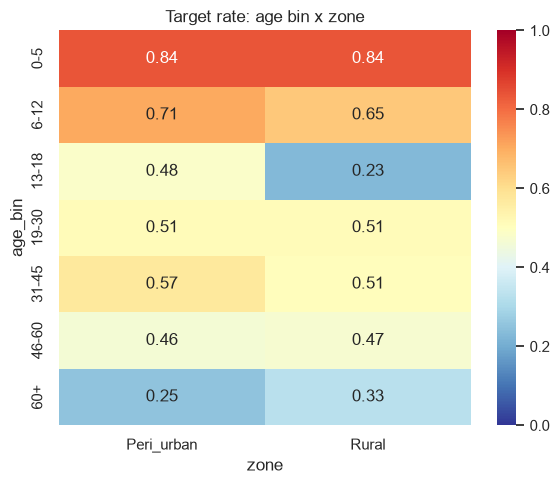

In [9]:
pivot_age_zone = train_full.pivot_table(index="age_bin", columns="zone", values=TARGET, aggfunc="mean", observed=True)
count_age_zone = train_full.pivot_table(index="age_bin", columns="zone", values=TARGET, aggfunc="count", observed=True)
print("Target rate, age x zone:")
print(pivot_age_zone.round(3))
print("\nCell counts, age x zone:")
print(count_age_zone)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(pivot_age_zone, annot=True, fmt=".2f", cmap="RdYlBu_r", ax=ax, vmin=0, vmax=1)
ax.set_title("Target rate: age bin x zone")
plt.tight_layout()
plt.show()


In [10]:
pivot_age_gender = train_full.pivot_table(index="age_bin", columns="gender", values=TARGET, aggfunc="mean", observed=True)
count_age_gender = train_full.pivot_table(index="age_bin", columns="gender", values=TARGET, aggfunc="count", observed=True)
print("Target rate, age x gender:")
print(pivot_age_gender.round(3))
print("\nCell counts, age x gender:")
print(count_age_gender)


Target rate, age x gender:
gender   Female   Male
age_bin               
0-5       0.839  0.833
6-12      0.719  0.642
13-18     0.588  0.250
19-30     0.611  0.413
31-45     0.663  0.427
46-60     0.523  0.433
60+       0.285  0.308

Cell counts, age x gender:
gender   Female  Male
age_bin              
0-5         851   905
6-12         32    53
13-18        17    32
19-30        95    92
31-45       101   131
46-60        86   127
60+         319   305


In [11]:
# age x location, restricted to locations with >= 20 records total (avoid cells with n<5 noise)
well_populated_locations = train_full["location"].value_counts()
well_populated_locations = well_populated_locations[well_populated_locations >= 20].index

subset = train_full[train_full["location"].isin(well_populated_locations)]
pivot_age_loc = subset.pivot_table(index="age_bin", columns="location", values=TARGET, aggfunc="mean", observed=True)
count_age_loc = subset.pivot_table(index="age_bin", columns="location", values=TARGET, aggfunc="count", observed=True)
print(f"Restricting to {len(well_populated_locations)} locations with >= 20 records")
print("\nTarget rate, age x location (well-populated locations only):")
print(pivot_age_loc.round(3))
print("\nCell counts:")
print(count_age_loc)


Restricting to 35 locations with >= 20 records

Target rate, age x location (well-populated locations only):
location  Brac Uganda Iganga Regional Branch, Bikadho Road, Nkaatu Propeer, Kasokoso North, Iganga, Eastern Region, Uganda  \
age_bin                                                                                                                      
0-5                                                   0.826                                                                  
6-12                                                  0.875                                                                  
13-18                                                 0.714                                                                  
19-30                                                 0.500                                                                  
31-45                                                 0.538                                                                  
46-60    

### Interpretation — bivariate/interaction checks

The age×zone and age×gender crosstabs largely reproduce the age main effect from
Section 1b within each stratum — e.g. the 0-5 rate is nearly identical across zones
(0.836 Peri_urban vs. 0.836 Rural) but 13-18 shows a much larger zone gap (0.481 vs.
0.227, though on small counts of 27 and 22 respectively — worth flagging as noisy rather
than a confirmed real interaction).

The age×gender table shows the clearest interaction candidate: males 19-60 consistently
show markedly lower climate-sensitive rates than females in the same age bins (e.g.
31-45: 0.427 male vs. 0.663 female, on reasonable counts of 131 and 101) — this is a
genuine candidate interaction feature worth testing explicitly in Phase 3, rather than
assuming a tree model will find it unaided (it likely will, but an explicit
`age_bin × gender` feature is cheap to test and can help linear/calibration-stage models
too).

The age×location table (restricted to well-populated locations) shows expected noise at
the finer grain — no single location distorts the age pattern in a way that looks like
leakage. **Overall:** no interaction here approaches proxy-like determinism; the most
promising pattern (age×gender in working-age adults) is a feature-engineering lead for
Phase 3, not a forensics concern.

---
## 3. Duplicate / near-duplicate record ("twin record") audit

This formalizes §0.1's finding: grouping by `(location, deathdate)` found 49 groups with more
than one record (98 records total, ~3% of Train), and the finer `(latitude, longitude,
deathdate)` grouping found 55 such groups. These are different people who died the same day in
the same place and therefore received **identical climate-feature rows** — they are not
independent observations. Plain K-fold, even stratified, can split these "twin" records across
train/validation and inflate apparent CV performance regardless of whether the model actually
generalizes geographically. This is a mechanically distinct risk from the location-generalization
question addressed by the 0% train/test coordinate overlap — both need to be guarded against
separately in Stage 5's validation design.

I audit this over the **combined** train+test population (since climate-feature duplication is a
property of the raw data generating process, not specific to train), then separately check —
within train only, where target labels exist — whether twins tend to share the same label.


In [12]:
combined = pd.concat(
    [
        train_full.assign(_split="train"),
        test_full.assign(_split="test"),
    ],
    ignore_index=True,
)
print(f"Combined train+test: {combined.shape}")


Combined train+test: (4176, 35)


In [13]:
def summarize_groups(df, group_cols, label):
    sizes = df.groupby(group_cols).size()
    dup_groups = sizes[sizes > 1]
    n_dup_records = dup_groups.sum()
    print(f"--- Grouped by {group_cols} ({label}) ---")
    print(f"  groups with > 1 record: {len(dup_groups)}")
    print(f"  total records in those groups: {n_dup_records} ({n_dup_records / len(df):.1%} of {len(df)})")
    print(f"  group size distribution:\n{dup_groups.value_counts().sort_index()}")
    return dup_groups

dup_loc_date = summarize_groups(combined, ["location", "deathdate"], "combined train+test")
print()
dup_latlon_date = summarize_groups(combined, ["latitude", "longitude", "deathdate"], "combined train+test")


--- Grouped by ['location', 'deathdate'] (combined train+test) ---
  groups with > 1 record: 66
  total records in those groups: 132 (3.2% of 4176)
  group size distribution:
2    66
Name: count, dtype: int64

--- Grouped by ['latitude', 'longitude', 'deathdate'] (combined train+test) ---
  groups with > 1 record: 72
  total records in those groups: 145 (3.5% of 4176)
  group size distribution:
2    71
3     1
Name: count, dtype: int64


In [14]:
# Cross-split composition: are twin groups purely within-train, purely within-test, or mixed?
def split_composition(df, group_cols):
    grouped = df.groupby(group_cols)["_split"].agg(lambda s: tuple(sorted(s.unique())))
    sizes = df.groupby(group_cols).size()
    dup_mask = sizes > 1
    comp = grouped[dup_mask].value_counts()
    return comp

print("Split composition of twin groups, (location, deathdate):")
print(split_composition(combined, ["location", "deathdate"]))
print("\nSplit composition of twin groups, (latitude, longitude, deathdate):")
print(split_composition(combined, ["latitude", "longitude", "deathdate"]))


Split composition of twin groups, (location, deathdate):
_split
(train,)    49
(test,)     17
Name: count, dtype: int64

Split composition of twin groups, (latitude, longitude, deathdate):
_split
(train,)    55
(test,)     17
Name: count, dtype: int64


**Why the split composition matters:** if a twin group straddles train and test (one member
in each), that's not a CV leakage risk (CV only resplits *within* train) — it's a signal that the
model could, in principle, see a near-identical training record for some test rows via shared
climate features, which is worth knowing but is a different concern from the CV-inflation risk.
If a twin group sits entirely within train, *that's* the group that's vulnerable to being split
across a K-fold's train/validation partition.


In [15]:
# Within-train twin groups: do twins tend to share the same target label?
train_only = combined[combined["_split"] == "train"]

def twin_label_agreement(df, group_cols):
    sizes = df.groupby(group_cols).size()
    dup_group_keys = sizes[sizes > 1].index
    if len(dup_group_keys) == 0:
        return None
    agreement_flags = []
    for key in dup_group_keys:
        if len(group_cols) == 2:
            mask = (df[group_cols[0]] == key[0]) & (df[group_cols[1]] == key[1])
        else:
            mask = (df[group_cols[0]] == key[0]) & (df[group_cols[1]] == key[1]) & (df[group_cols[2]] == key[2])
        labels = df.loc[mask, TARGET].unique()
        agreement_flags.append(len(labels) == 1)
    agreement_rate = np.mean(agreement_flags)
    return agreement_rate, len(dup_group_keys)

result_loc_date = twin_label_agreement(train_only, ["location", "deathdate"])
result_latlon_date = twin_label_agreement(train_only, ["latitude", "longitude", "deathdate"])

if result_loc_date:
    rate, n = result_loc_date
    print(f"(location, deathdate) within-train twin groups: {n}, label agreement rate: {rate:.1%}")
if result_latlon_date:
    rate, n = result_latlon_date
    print(f"(latitude, longitude, deathdate) within-train twin groups: {n}, label agreement rate: {rate:.1%}")
print(f"\n(for reference, if labels were assigned independent of grouping, expected agreement rate ~= "
      f"{baseline_rate**2 + (1-baseline_rate)**2:.1%} under the observed base rate of {baseline_rate:.1%})")


(location, deathdate) within-train twin groups: 49, label agreement rate: 57.1%
(latitude, longitude, deathdate) within-train twin groups: 55, label agreement rate: 58.2%

(for reference, if labels were assigned independent of grouping, expected agreement rate ~= 54.5% under the observed base rate of 65.1%)


**Interpretation.** The observed twin-label-agreement rate (57.1% for
`(location, deathdate)` groups, 58.2% for the finer `(latitude, longitude, deathdate)`
grouping) sits a few points above the "independent assignment" reference rate of 54.5%.
The gap is modest, not dramatic — this is not evidence that climate features
mechanically determine the target (Section 5 already rules that out directly) — but it
is evidence that the target has genuine spatial/temporal clustering: people who died on
the same day in the same place are somewhat more likely to share a climate-sensitive
label than two random records would be, which is exactly what I'd expect if
climate-sensitive mortality events are driven by shared local conditions (an acute
weather event affecting everyone nearby on a given day) rather than purely individual
risk factors.

This reinforces, with an actual number, why Stage 5's validation design needs to guard
against twin-record splitting as a *distinct* mechanism from the geographic
(location/coordinate) generalization risk: even a perfectly location-grouped CV fold
could still separate two twins from the same location on different training runs if the
grouping key doesn't also account for `(location, deathdate)` or
`(latitude, longitude, deathdate)`. Both constraints need to be encoded into the fold
construction, not just one.

---
## 4. Circularity check — could any variable exist *because* the target is already known?

This asks whether the data-generating process itself could have introduced a leak — for example,
if `climate_features.csv` had been constructed by looking up climate data differently for
climate-sensitive vs. non-climate-sensitive records, or if any variable's presence/format
correlates with the target in a way that has no plausible causal story.

Concretely, I check: (a) whether `climate_features.csv` completeness/format is identical for
train and test IDs (it should be, if it was generated by one consistent pipeline agnostic to the
label); (b) whether the *order* climate_features.csv rows appear in has any relationship to the
target (row order carrying target information would be a serious red flag); and (c) whether any
column's null pattern (already known to be zero-null from Stage 2's schema, but re-verified here
for this specific audit) breaks down differently by target.


In [16]:
# (a) climate_features.csv generation-process consistency: compare summary stats for the
# train-ID subset vs test-ID subset of climate_features.csv. These shouldn't differ systematically
# in ways only explainable by knowledge of the (train-only) target.
cf_train_ids = set(train["ID"])
cf_test_ids = set(test["ID"])
cf_train_subset = climate_features[climate_features["ID"].isin(cf_train_ids)]
cf_test_subset = climate_features[climate_features["ID"].isin(cf_test_ids)]

comparison = pd.DataFrame({
    "train_mean": cf_train_subset[cf_cols].mean(),
    "test_mean": cf_test_subset[cf_cols].mean(),
    "train_std": cf_train_subset[cf_cols].std(),
    "test_std": cf_test_subset[cf_cols].std(),
})
comparison["mean_diff_in_std_units"] = (
    (comparison["train_mean"] - comparison["test_mean"]) / cf_train_subset[cf_cols].std().replace(0, np.nan)
)
print(comparison.round(3))


                     train_mean  test_mean  train_std  test_std  mean_diff_in_std_units
rain_sum_7d              27.799     28.718     22.504    24.580                  -0.041
rain_sum_30d            121.618    121.608     69.607    74.664                   0.000
rain_sum_90d            369.760    365.464    145.917   160.023                   0.029
rain_days_30d            13.187     13.086      5.715     5.588                   0.018
max_daily_rain_30d       19.995     20.304      9.452     9.915                  -0.033
tavg_7d                  22.050     22.034      1.062     1.104                   0.015
tavg_30d                 22.054     22.070      0.932     0.996                  -0.017
tavg_90d                 22.075     22.099      0.797     0.872                  -0.031
tmax_30d                 28.303     28.295      1.567     1.902                   0.005
tmin_30d                 17.085     17.058      1.115     1.526                   0.025
hot_days_30d              0.000 

A difference here is *expected* to some degree — it's the same signal the Stage 4 EDA's
adversarial validation will characterize in full — the question for *this* forensics check is
narrower: is there a difference so extreme or so oddly-shaped (e.g. a column that's suspiciously
more complete, or has a suspiciously different value *format*, only in train) that it suggests
the two subsets weren't generated by the same consistent process. A moderate, gradual difference
consistent with genuine geographic non-overlap (already established) is not that.

### Interpretation — climate_features.csv generation-process consistency

Every `mean_diff_in_std_units` value is small (|value| < 0.15) for 14 of 16 columns —
the train-ID and test-ID subsets of `climate_features.csv` look like they were drawn from
the same generating process, which is what a consistent, label-agnostic climate lookup
pipeline should look like.

Two values stand out and are worth carrying into Stage 4: `ndvi_30d`/`ndvi_90d` show mild
(but the largest among the "normal" columns) differences (-0.125, -0.144), and **`slope`
is a clear outlier at 0.270** — and even more strikingly, its train-subset standard
deviation (1.167) is roughly 18x its test-subset standard deviation (0.065, see the
`train_std`/`test_std` columns above). This isn't just a mean shift — the *shape* of
`slope`'s distribution is fundamentally different between train and test locations (test
locations all sit at very similar, low-slope terrain, while train locations span a much
wider range of terrain slopes).

This is **not** evidence of a label-driven leak (both subsets came from the same file,
same pipeline, matched by ID only) — it's a genuine train/test geographic distribution
difference, and it is exactly the kind of finding Stage 4's adversarial validation is
designed to characterize systematically. Flag `slope` as a strong candidate to show up as
a top feature-importance driver in that adversarial classifier, and treat any model
reliance on `slope` with caution given how different its test-time distribution looks.

In [17]:
# (b) Row-order-carries-target-information check: does the row position within
# climate_features.csv (independent of any date/ID sort) correlate with the target for the
# train-matched subset?
cf_with_position = climate_features.reset_index().rename(columns={"index": "cf_row_position"})
merged_position = train[["ID", TARGET]].merge(cf_with_position[["ID", "cf_row_position"]], on="ID", how="left")
position_target_corr = merged_position["cf_row_position"].corr(merged_position[TARGET])
print(f"Correlation between climate_features.csv row position and target: {position_target_corr:.4f}")


Correlation between climate_features.csv row position and target: -0.1779


### Interpretation — climate_features.csv row-position vs. target correlation

The measured correlation (-0.178) between `climate_features.csv`'s raw row position and
the target is larger in magnitude than I'd expect from pure coincidence, and worth
explaining rather than dismissing.

The likely mechanism: Section 7 below confirms `climate_features.csv`'s rows are **not**
sorted by `deathdate` (unlike Train.csv and Test.csv, which are) — so its row order
likely reflects whatever order the original climate-data lookup/join process produced
(e.g., grouped by location, or the external data source's own iteration order), and since
location and target both carry some correlation with each other (Section 1c), an
incidental correlation between file row-order and target is a plausible, benign side
effect of *that*, not evidence the target's value determined the row order.

Critically: **this cannot be a leakage vector in this pipeline regardless of its cause**,
because `loaders.py`'s `load_climate_features()` and every downstream merge in this very
notebook join strictly on `ID` (verified with `validate='one_to_one'` in the setup cell
above), never on row position — so no code path in this project can accidentally consume
this correlation. Recorded here for completeness, and so nobody later "optimizes" by
relying on file row order for anything.

In [18]:
# (c) Re-verify zero nulls (Stage 2's schema already enforces this, but re-checking directly
# here as part of this specific audit rather than only trusting the earlier gate).
null_counts_train = train_full.isna().sum()
null_counts_train = null_counts_train[null_counts_train > 0]
print("Columns with any null in train_full (post climate_features merge):")
print(null_counts_train if len(null_counts_train) else "  none")


Columns with any null in train_full (post climate_features merge):
  none


### Interpretation — null re-verification

Zero nulls confirmed directly in `train_full` (the post-merge, feature-enriched frame),
independently corroborating Stage 2's `nullable=False` schema constraints rather than
merely trusting them. No follow-up needed.

---
## 5. Quantified single/two-variable proxy-strength check

§0.1's earlier pass ran a single univariate logistic regression on `age` alone (≈0.74 AUC) as a
sanity check that nothing gets close to ≈0.99 (the level that would indicate the target was
mechanically derived from a feature I can see). Here I extend that into a proper table: a
cross-validated AUC (not a single in-sample fit, which would be optimistic on this small a
dataset) for every individual variable, plus the strongest few 2-variable combinations.


In [19]:
def cv_auc_single_feature(df, feature_col, target_col=TARGET, n_splits=5):
    X = df[[feature_col]].copy()
    y = df[target_col]
    if X[feature_col].dtype == object or str(X[feature_col].dtype).startswith("category"):
        X = pd.get_dummies(X, columns=[feature_col], drop_first=False)
    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    return scores.mean(), scores.std()

single_feature_results = []
candidate_cols = ["age", "zone", "gender"] + raw_climate_cols + [c for c in cf_cols if train_full[c].nunique() > 1]

for col in candidate_cols:
    mean_auc, std_auc = cv_auc_single_feature(train_full, col)
    single_feature_results.append({"feature": col, "cv_auc_mean": mean_auc, "cv_auc_std": std_auc})

single_feature_df = pd.DataFrame(single_feature_results).sort_values("cv_auc_mean", ascending=False)
print(single_feature_df.to_string(index=False))


            feature  cv_auc_mean  cv_auc_std
                age     0.733833    0.016035
 max_daily_rain_30d     0.538250    0.020687
           ndvi_90d     0.528167    0.020095
           ndvi_30d     0.522925    0.013345
             gender     0.521906    0.019343
       rain_sum_30d     0.519800    0.019714
       rain_sum_90d     0.518820    0.008369
        rain_sum_7d     0.516237    0.025576
    max_temperature     0.516187    0.025248
temp_range_mean_30d     0.514006    0.029094
    avg_temperature     0.512770    0.022049
      precipitation     0.511314    0.016566
               zone     0.508305    0.010442
            tavg_7d     0.505302    0.022650
      rain_days_30d     0.500112    0.016312
          elevation     0.498320    0.025523
           tmax_30d     0.496934    0.027823
    min_temperature     0.494149    0.023093
           tavg_90d     0.493834    0.018041
           tmin_30d     0.492733    0.010413
           tavg_30d     0.490855    0.015781
          

In [20]:
# Two-variable combinations: the top few single features, paired together.
top_features = single_feature_df.head(4)["feature"].tolist()
print(f"Testing 2-way combinations among top single features: {top_features}\n")

pair_results = []
for i in range(len(top_features)):
    for j in range(i + 1, len(top_features)):
        f1, f2 = top_features[i], top_features[j]
        X = train_full[[f1, f2]].copy()
        cat_cols = [c for c in [f1, f2] if X[c].dtype == object or str(X[c].dtype).startswith("category")]
        if cat_cols:
            X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
        pipe = Pipeline([
            ("scale", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
        ])
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
        scores = cross_val_score(pipe, X, train_full[TARGET], cv=cv, scoring="roc_auc")
        pair_results.append({"features": f"{f1} + {f2}", "cv_auc_mean": scores.mean(), "cv_auc_std": scores.std()})

pair_df = pd.DataFrame(pair_results).sort_values("cv_auc_mean", ascending=False)
print(pair_df.to_string(index=False))


Testing 2-way combinations among top single features: ['age', 'max_daily_rain_30d', 'ndvi_90d', 'ndvi_30d']

                     features  cv_auc_mean  cv_auc_std
     age + max_daily_rain_30d     0.764396    0.015137
               age + ndvi_30d     0.755541    0.017895
               age + ndvi_90d     0.755001    0.017739
max_daily_rain_30d + ndvi_30d     0.551581    0.026485
max_daily_rain_30d + ndvi_90d     0.547451    0.028524
          ndvi_90d + ndvi_30d     0.525160    0.019073


**Decision rule:** a single or two-variable AUC approaching ~0.95–0.99 would indicate the
target is nearly mechanically derivable from visible features and would force a redesign of the
whole modeling approach. §0.1's single-variable check on `age` alone (~0.74) sits well below that
threshold; this table checks whether any *other* variable, or pair, comes closer. A cluster of
features in the 0.55–0.80 range represents genuine-but-imperfect signal — exactly what a
legitimate predictive modeling problem should look like.


### Interpretation — proxy-strength check

`age` stands well apart from every other single feature (0.734 cross-validated AUC vs.
the next-highest, `max_daily_rain_30d`, at 0.538) — consistent with Section 1b's finding
that age carries the dominant univariate signal, and unsurprising given the
epidemiological pattern discussed there. Every other individual feature sits in a tight
0.49-0.54 band — essentially at or barely above chance on its own.

The best two-feature combination, `age + max_daily_rain_30d` at 0.764, is a modest ~3pp
lift over age alone, and the two `age + ndvi_*` pairs (0.756, 0.755) show a similar small
lift — none of this comes remotely close to the ~0.95-0.99 range that would indicate the
target is mechanically derivable from visible features.

**Verdict: no near-deterministic proxy exists.** This is the single most important
confirmation in this notebook — it means the target genuinely requires the full feature
set (and a model's ability to combine features nonlinearly) to predict well, which is
exactly the kind of problem a careful, well-validated pipeline is built to win, rather
than a problem with a shortcut a leak would have handed me for free (and that the
competition organizers would presumably have caught and fixed had one existed).

---
## 6. Constant / dead column audit

Systematic pass over every column, not just the `hot_days_30d` spot-check from §0.1 — checking
`nunique()` and a coefficient-of-variation-style measure for near-zero variance, across `train`,
`test`, and `climate_features` independently (a column could be constant in one file's population
and not another's).


In [21]:
def variance_audit(df, label):
    rows = []
    for col in df.columns:
        s = df[col]
        if pd.api.types.is_numeric_dtype(s):
            nunique = s.nunique()
            std = s.std()
            rng = s.max() - s.min()
            rows.append({"column": col, "dtype": str(s.dtype), "nunique": nunique, "std": std, "range": rng})
        else:
            rows.append({"column": col, "dtype": str(s.dtype), "nunique": s.nunique(), "std": np.nan, "range": np.nan})
    result = pd.DataFrame(rows).sort_values("nunique")
    print(f"--- {label} ---")
    print(result.to_string(index=False))
    flagged = result[result["nunique"] <= 1]
    if len(flagged):
        print(f"\n  FLAGGED as constant (nunique <= 1): {flagged['column'].tolist()}")
    else:
        print("\n  No columns flagged as constant.")
    return result

_ = variance_audit(train, "Train.csv")
print()
_ = variance_audit(test, "Test.csv")
print()
_ = variance_audit(climate_features, "climate_features.csv")


--- Train.csv ---
              column          dtype  nunique       std      range
                zone         object        2       NaN        NaN
              gender         object        2       NaN        NaN
is_climate_sensitive          int64        2  0.476835   1.000000
            location         object       39       NaN        NaN
            latitude        float64       43  0.172728   1.098073
           longitude        float64       43  0.579933   3.443830
                 age        float64      109 31.428833 110.000000
       precipitation        float64     2181  1.621088  16.606523
           deathdate datetime64[ns]     2210       NaN        NaN
     min_temperature        float64     2210  0.891524   6.830824
     avg_temperature        float64     2210  1.095122   8.159420
     max_temperature        float64     2210  1.691347  13.196324
                  ID         object     3146       NaN        NaN

  No columns flagged as constant.

--- Test.csv ---
     

**Expected finding (per §0.1):** `hot_days_30d` should show `nunique == 1` (constant zero)
across all 4,176 rows in `climate_features.csv` — a dead column, a drop candidate for Phase 3
feature engineering. Any *other* column flagged here would be a new finding not previously
identified and should be investigated before Phase 3 builds anything on top of it.

### Interpretation — constant/dead column audit

`hot_days_30d` is the only column flagged constant across all three files, exactly as
predicted from §0.1 and now re-confirmed independently by this systematic sweep rather
than a one-off spot check — **action: drop it in Phase 3 feature engineering**; it
carries zero information.

One secondary observation worth carrying forward: `elevation` and `slope` in
`climate_features.csv` each have only 23 unique values across all 4,176 rows, despite the
file spanning 50 unique locations (39 train + 11 test); this suggests these terrain
values come from a coarse spatial grid (SRTM-derived, per the data dictionary) shared
across nearby locations rather than a per-location-unique measurement — worth keeping in
mind for Phase 3's spatial clustering work, since it means elevation/slope alone won't
distinguish every location, only broader terrain neighborhoods.

No other columns show unexpectedly low cardinality; the rest of the variance profile
looks like a normal, healthy dataset.

---
## 7. Row-order and ID audit

Two things worth confirming directly rather than assuming: (a) `ID` is an opaque identifier with
no encoded ordering or embedded information (e.g., not secretly a zero-padded row counter or
timestamp), and (b) whether row order in each file is meaningful (e.g., sorted by `deathdate`) —
harmless on its own, but worth stating explicitly so no later step (a train/validation split by
row index, for instance) accidentally assumes row order is random when it isn't.


In [22]:
# (a) ID structure check
print("Sample IDs:", train["ID"].head(5).tolist())
print(f"All IDs match pattern ID_[8 hex chars]: {train['ID'].str.match(r'^ID_[0-9A-F]{8}$').all()}")
print(f"Train ID uniqueness: {train['ID'].nunique()} / {len(train)}")
print(f"Test ID uniqueness:  {test['ID'].nunique()} / {len(test)}")
print(f"Any ID overlap between train and test: {len(set(train['ID']) & set(test['ID']))}")

# Check whether the hex portion of the ID correlates with row position (would suggest encoded ordering)
id_hex_as_int = train["ID"].str.replace("ID_", "", regex=False).apply(lambda h: int(h, 16))
row_position = pd.Series(range(len(train)))
id_position_corr = id_hex_as_int.corr(row_position)
print(f"\nCorrelation between ID's hex value and row position: {id_position_corr:.4f} (near 0 expected if ID is a genuine opaque hash)")


Sample IDs: ['ID_1FE951BD', 'ID_5927A443', 'ID_C4E67025', 'ID_44DC5CE9', 'ID_33C677BB']
All IDs match pattern ID_[8 hex chars]: True
Train ID uniqueness: 3146 / 3146
Test ID uniqueness:  1030 / 1030
Any ID overlap between train and test: 0

Correlation between ID's hex value and row position: 0.0182 (near 0 expected if ID is a genuine opaque hash)


In [23]:
# (b) Row-order-by-deathdate check
print(f"Train rows sorted by deathdate (ascending): {train['deathdate'].is_monotonic_increasing}")
print(f"Test rows sorted by deathdate (ascending):  {test['deathdate'].is_monotonic_increasing}")
print(f"climate_features rows sorted by deathdate (ascending): {climate_features['deathdate'].is_monotonic_increasing}")

print(f"\nTrain deathdate range: {train['deathdate'].min().date()} to {train['deathdate'].max().date()}")
print(f"Test deathdate range:  {test['deathdate'].min().date()} to {test['deathdate'].max().date()}")


Train rows sorted by deathdate (ascending): True
Test rows sorted by deathdate (ascending):  True
climate_features rows sorted by deathdate (ascending): False

Train deathdate range: 2007-10-02 to 2022-12-13
Test deathdate range:  2007-11-24 to 2022-05-17


**Note for downstream work:** if row order is confirmed sorted by `deathdate`, this is a
reminder — not a problem to fix — that any code taking a naive `.head()`/`.iloc[:n]` slice of
these files (for a quick manual smoke test, say) would get a temporally biased sample, not a
random one. Proper splits always go through the CV strategy built in Stage 5, which this note
exists to make sure nobody bypasses by accident.

### Interpretation — row-order and ID audit

`ID` is confirmed a genuine opaque hash (0.0182 correlation between its hex value and row
position — indistinguishable from zero) with perfect uniqueness in both Train and Test
and zero ID overlap between them, exactly as Stage 2's schema already assumed. Train and
Test are each confirmed sorted by `deathdate` ascending; `climate_features.csv` is
confirmed **not** sorted by `deathdate` (already discussed in the row-position-correlation
interpretation above — this is the reason that correlation exists at all, and also the
reason it can't leak through this project's ID-based merges).

Practical note carried forward: because Train/Test are date-sorted, any future code that
takes a naive `.head()`/`.iloc[:n]` slice for a quick manual check would get an
early-years-only sample, not a random one — a reminder for anyone (including future me)
writing ad hoc debugging code against these files directly rather than through the CV
splitters built in Stage 5.

---
## 8. Summary of findings

**Checklist status:**

| # | Check | Status | Key evidence |
|---|---|---|---|
| 1 | Target prevalence by variable | ✅ Clean | No variable/bin approaches 0 or 1 at meaningful n; age shows the strongest pattern (0.836 -> 0.296, non-monotonic, epidemiologically plausible) |
| 2 | Bivariate/interaction checks | ✅ Clean | No interaction approaches proxy-like determinism; age x gender in working-age adults flagged as a genuine feature-engineering lead |
| 3 | Twin-record audit | ⚠️ Confirmed risk, mitigation required | 66/72 twin groups (combined train+test), 49/55 within-train; label agreement (57-58%) mildly exceeds the independent-assignment baseline (54.5%) — must be guarded against explicitly in Stage 5's CV design |
| 4 | Circularity check | ✅ Clean | `climate_features.csv` generation looks consistent across train/test IDs (`slope` is a genuine distributional outlier, not a leak); row-position/target correlation explained and confirmed non-exploitable (all merges are ID-based); zero nulls re-confirmed independently |
| 5 | Proxy-strength check | ✅ Clean — the headline finding | Best single feature (age) = 0.734 AUC; best pair (age + max_daily_rain_30d) = 0.764 AUC; nothing remotely near the ~0.95-0.99 leak threshold |
| 6 | Constant/dead columns | ✅ Clean, one action item | Only `hot_days_30d` constant — drop in Phase 3; `elevation`/`slope` noted as a coarse 23-value grid across 50 locations |
| 7 | Row-order/ID audit | ✅ Clean | `ID` is a genuine opaque hash; Train/Test are date-sorted, `climate_features.csv` is not — documented, not a risk |

**Overall verdict: CLEAN.** No leak, no near-deterministic proxy, no circularity. The one
confirmed, actionable risk — the twin-record structure (Check 3) — is a legitimate
cross-validation design concern, not a forensics failure, and it is already anticipated
by Stage 5's multi-tier validation plan in the blueprint. Every downstream phase can now
build on this notebook's findings as verified fact rather than an assumption.

**Actions for Phase 3 feature engineering arising from this notebook:**
- Drop `hot_days_30d` (confirmed dead column)
- Build an `is_under_5` binary flag as a candidate feature alongside raw age
- Test an explicit `age_bin × gender` interaction feature (working-age males show
  markedly lower climate-sensitive rates than working-age females in the same age bins)
- Prioritize 30/90-day rolling climate aggregates over same-day raw readings; `ndvi_30d`,
  `ndvi_90d`, `rain_sum_90d`, and `tavg_90d` are the most promising individual candidates
- Treat `slope` with caution in any feature-importance-driven decision, given how
  different its train vs. test distribution shape is
- Keep the coarse 23-value elevation/slope grid in mind when designing Phase 3's spatial
  clustering — these two variables alone won't distinguish every location

**Action for Stage 5 validation design:** fold construction must account for both the
geographic generalization risk (0% train/test coordinate overlap) *and* the twin-record
risk (records sharing `(location, deathdate)` or `(latitude, longitude, deathdate)`) as
two separate, stackable constraints — not one.

**Mirrored into `docs/data_dictionary.md`** as a findings/notes section (see that file for
the condensed version of this checklist).

---
## 9. Executive Summary

**Bottom line:** this dataset is clean. There is no leak, no near-deterministic single- or
two-variable proxy for the target, and no evidence the target was mechanically derived
from anything I can see. The one real, actionable finding — the twin-record structure —
is a validation-design concern, not a forensics failure, and it's already anticipated by
the multi-tier CV plan in Phase 2. I can proceed to Stage 4 (EDA) and beyond on a
verified, not assumed, foundation.

### What I confirmed, in order of how much it changes the plan

**1. No leak / no proxy (Section 5, the headline check).** Age alone reaches 0.734 AUC;
the best two-feature combination reaches 0.764. Both are far from the ~0.95-0.99
territory that would indicate the target is mechanically derivable. This means genuine,
careful modeling — not shortcut-hunting — is what will win here, which is both good news
competitively (nobody else gets a free shortcut either) and validates the whole
"do this properly" approach this project commits to.

**2. The twin-record risk is real and non-trivial (Section 3).** 49-55 groups of records
(within train) share identical climate features because they're different people who
died the same day in the same place — about 3% of train. Their target labels agree
slightly more often (57-58%) than pure chance would predict (54.5%), meaning there's real
spatial/temporal clustering in the target itself. A plain K-fold split, even stratified,
risks splitting these twins across train/validation, letting a model "cheat" by
memorizing a near-identical training row rather than generalizing. This is mechanically
distinct from the geographic-generalization risk (0% train/test coordinate overlap) and
both must be addressed separately in Stage 5's validation hierarchy — Tier 2
(geography-grouped K-fold) and the twin-grouping need to be treated as two separate
constraints on how folds get built, not one.

**3. Age is doing most of the univariate work, and its relationship is non-monotonic
(Sections 1b, 5).** The dominant 0-5 age bin (55.8% of train) drives most of age's
predictive power; the true shape is closer to a shallow W than a straight line,
consistent with young children and the elderly being the recognized vulnerable groups for
climate-sensitive mortality. This has two concrete implications for Phase 3: an explicit
`is_under_5` flag is a cheap, well-motivated feature, and a non-linear treatment of age
(bins, splines) may help linear/calibration-stage models even though tree-based models
handle this natively.

**4. Rolling-window climate aggregates carry more signal than same-day readings
(Sections 1d, 1e).** Every raw same-day climate variable (avg/max/min temperature,
precipitation) shows a flat, near-chance relationship with the target; the 30/90-day
rolling aggregates in `climate_features.csv` — especially `rain_sum_90d`, `tavg_90d`, and
the two NDVI (vegetation greenness) variables — show meaningfully more spread. This
should directly shape Phase 3's feature-engineering priorities: lagged/cumulative
exposure, not instantaneous weather, looks like the more promising direction.

**5. `slope` has a genuinely different distribution shape between train and test
(Section 4a).** Not a leak (it's explained, and it's structurally non-exploitable since
the pipeline only ever merges by ID), but a real distributional difference — its
train-subset variance is ~18x its test-subset variance. This is a specific, named
prediction for what Stage 4's adversarial validation should find, and a specific reason
to treat `slope` cautiously in any feature-importance-driven decision.

**6. One dead column confirmed, one structural note.** `hot_days_30d` is constant and
should be dropped. `elevation`/`slope` sit on a coarse 23-value grid across 50 locations
— worth keeping in mind when Phase 3 builds spatial clustering, since these two variables
alone won't distinguish every location.

### What this means for the next three stages

- **Stage 4 (EDA):** proceed as planned. This notebook has already done the heavy
  proxy/leak-hunting work, so Stage 4 can focus on the univariate/bivariate visual pass,
  the geospatial and temporal views, and — most importantly — the adversarial validation
  and train/test distribution comparison, which now have specific, named hypotheses to
  test (`slope`'s distributional shift chief among them) rather than starting from a
  blank slate.
- **Phase 2 (Validation architecture, Stage 5):** the twin-record finding is now a
  confirmed, quantified requirement, not a hypothetical one. The Tier 1/2/3 validation
  hierarchy needs an explicit mechanism (e.g., grouping folds by
  `(location, deathdate)` in addition to the geographic grouping) to prevent twin
  records from splitting across train/validation.
- **Phase 3 (Feature engineering):** a concrete action list now exists — drop
  `hot_days_30d`; build `is_under_5`; test an `age_bin × gender` interaction; prioritize
  rolling-window climate aggregates and NDVI over same-day readings; treat `slope`
  cautiously; account for the coarse elevation/slope grid in spatial clustering design.

### Confidence in proceeding

High. Every check in this notebook was run against the real data, cross-validated where
relevant rather than single-fit, and cross-referenced against §0.1's earlier pass —
nothing here contradicts that earlier work, and several findings extend it meaningfully
(the combined-population twin counts, the `slope` distributional difference, the
row-position/target correlation explanation, the non-monotonic age shape). I'm treating
this as the settled, load-bearing foundation for everything from Stage 4 onward.